In [1]:
## 1. Setup Paths

import sys
import os
from pathlib import Path

# Add source directory to path
# Assumes this notebook is in a 'notebooks' folder, and 'src' is one level up
current_path = Path.cwd()
base_project_dir = current_path.parent
src_dir = base_project_dir / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

# Define key directories
dataset_directory = src_dir / "abstractionssymh" / "dataset"
saved_directory = src_dir / "abstractionssymh" / "saved"
saved_models_L1_dir = saved_directory / "models_L1"
saved_models_L2_dir = saved_directory / "models_L2"

# Create directories
saved_directory.mkdir(parents=True, exist_ok=True)
saved_models_L1_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_dir.mkdir(parents=True, exist_ok=True)

print(f"Base project directory: {base_project_dir}")
print(f"Source directory: {src_dir}")
print(f"Saved directory: {saved_directory}")
print(f"L1 Models directory: {saved_models_L1_dir}")
print(f"L2 Models directory: {saved_models_L2_dir}")

Base project directory: c:\Users\Amogh\abstraction-discovery
Source directory: c:\Users\Amogh\abstraction-discovery\src
Saved directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved
L1 Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L1
L2 Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L2


In [2]:
## 2. Imports

import pickle
import random
import re
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.mixture import GaussianMixture

# Project-specific imports
from abstractionssymh.debug_utils import debug_info, debug_error, debug_success
from abstractionssymh.data_loader import parse_json_to_dsl
from abstractionssymh.plot_utils import plot_dsl_with_k3d, plot_dsl_grid
from abstractionssymh.dsl_utils import collect_singleton_and_pair_data, find_all_subtrees
from abstractionssymh.abstraction_utils import (
    find_abstractions, 
    find_abstractions_pca,
    integrate_abstractions, 
    Abstraction,
    Autoencoder, 
    PCAModel,
    DEVICE,
    make_safe_filename
)
from abstractionssymh.dsl_nodes import Box # Used for type checking

# Helper function from your notebook (cell [18]) for clustering
def cluster_key_with_gmm(data_dict, pattern_key, max_clusters=8, verbose=True):
    """
    Clusters the points for a given key using a Gaussian Mixture Model (GMM).
    Automatically finds the optimal number of clusters using BIC.
    """
    data_dict = data_dict.copy()
    if pattern_key not in data_dict:
        debug_error(f"'{pattern_key}' not found in dictionary.")
        return data_dict

    records = data_dict.pop(pattern_key)
    df = pd.DataFrame(records)
    param_df = pd.DataFrame(df['params'].to_list())
    param_values = param_df.values

    if len(param_values) < max_clusters:
        debug_info(f"Warning: Not enough data for '{pattern_key}' ({len(param_values)} points) to test {max_clusters} clusters. Skipping.")
        data_dict[pattern_key] = records # Add it back unchanged
        return data_dict

    n_components_range = range(1, max_clusters + 1)
    bic_scores = []
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(param_values)
        bic_scores.append(gmm.bic(param_values))

    optimal_n_components = np.argmin(bic_scores) + 1
    if verbose:
        debug_info(f"Clustering '{pattern_key}': Optimal clusters = {optimal_n_components}")

    final_gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
    cluster_labels = final_gmm.fit_predict(param_values)

    for cluster_id in range(optimal_n_components):
        cluster_records = df.iloc[cluster_labels == cluster_id].to_dict(orient='records')
        new_key = f"{pattern_key}_cluster{cluster_id}"
        data_dict[new_key] = cluster_records
        if verbose:
            debug_info(f"  -> {new_key}: {len(cluster_records)} points")

    return data_dict

print("All libraries and helpers imported.")

All libraries and helpers imported.


In [3]:
# In[3]:
## 3. Load Chairs (L1 Dataset)

# --- CONFIGURATION ---
# Set a limit on the number of chairs to load for faster testing.
# Set to None to load all chairs.
CHAIR_LIMIT = None 
# ---

pickle_file = saved_directory / "all_dsl_shapes.pkl"
all_dsl_shapes = {} # This will be our final, limited dictionary
full_dsl_shapes = {} # This will hold the complete dataset

if pickle_file.exists():
    debug_info(f"Loading L1 DSL shapes from pickle: {pickle_file}")
    with open(pickle_file, "rb") as f:
        # Load the full dictionary first
        full_dsl_shapes = pickle.load(f)
    debug_success(f"Loaded {len(full_dsl_shapes)} total shapes from pickle.")
else:
    debug_info(f"Pickle file not found: {pickle_file}")
    debug_info("--- Generating new pickle from JSON files ---")
    
    # --- Step 1: Define directory ---
    # This path is defined in cell [1]
    chair_directory = dataset_directory / "Chair"
    if not chair_directory.exists():
        debug_error(f"Chair dataset directory not found at: {chair_directory}")
    
    # --- Step 2: Load DSL objects from JSON files ---
    debug_info("--- Step 2.1: Loading DSL objects from JSON files ---")
    json_files = sorted(list(chair_directory.glob("*.json"))) # Convert generator to list
    if not json_files:
        debug_error(f"No JSON files found in {chair_directory}")

    for json_file in tqdm(json_files, desc="Loading JSON files"):
        try:
            json_content = json_file.read_text(encoding="utf-8")
            dsl_obj = parse_json_to_dsl(json_content)
            full_dsl_shapes[json_file.name] = {
                "dsl": dsl_obj,
                "singleton_params": {},
                "pair_params": {},
            }
        except Exception as e:
            debug_error(f"Failed to load {json_file.name}: {e}")

    debug_info(f"Loaded {len(full_dsl_shapes)} DSL shapes into memory.")

    # --- Step 3: Collect parameters ---
    debug_info("\n--- Step 2.2: Collecting parameters for each shape ---")
    for name, data in tqdm(full_dsl_shapes.items(), desc="Collecting parameters"):
        dsl_obj = data["dsl"]
        # Use the imported function
        singletons, pairs = collect_singleton_and_pair_data([dsl_obj])
        data["singleton_params"] = singletons
        data["pair_params"] = pairs

    debug_success("Populated singleton and pair parameters for all shapes.")

    # --- Step 4: Save to pickle ---
    try:
        with open(pickle_file, "wb") as f:
            pickle.dump(full_dsl_shapes, f)
        debug_success(f"Saved all {len(full_dsl_shapes)} shapes to {pickle_file}")
    except Exception as e:
        debug_error(f"Failed to save pickle file: {e}")

# --- APPLY CHAIR_LIMIT (runs after loading OR generating) ---
if full_dsl_shapes:
    if CHAIR_LIMIT is not None and len(full_dsl_shapes) > CHAIR_LIMIT:
        debug_info(f"Limiting dataset to {CHAIR_LIMIT} chairs (out of {len(full_dsl_shapes)}).")
        # Convert to list, slice, and convert back to dict
        limited_items = list(full_dsl_shapes.items())[:CHAIR_LIMIT]
        all_dsl_shapes = dict(limited_items)
    else:
        debug_info(f"Using all {len(full_dsl_shapes)} loaded chairs (no limit set or limit not exceeded).")
        all_dsl_shapes = full_dsl_shapes
        
    debug_success(f"Final dataset size: {len(all_dsl_shapes)} shapes.")
else:
    debug_error("No shapes were loaded or generated.")

# Display a sample
if all_dsl_shapes:
    sample_key = list(all_dsl_shapes.keys())[0]
    print(f"\nSample shape '{sample_key}' keys: {all_dsl_shapes[sample_key].keys()}")
    # print(f"Sample DSL:\n{all_dsl_shapes[sample_key]['dsl']}")

[INFO] Loading L1 DSL shapes from pickle: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\all_dsl_shapes.pkl
[SUCCESS] Loaded 6201 total shapes from pickle.
[INFO] Using all 6201 loaded chairs (no limit set or limit not exceeded).
[SUCCESS] Final dataset size: 6201 shapes.

Sample shape 'Chair_1.json' keys: dict_keys(['dsl', 'singleton_params', 'pair_params'])


In [4]:
# from abstractionssymh.abstraction_utils import Abstraction
# from abstractionssymh.dsl_nodes import Box
# from collections.abc import Iterable

# def get_structural_key(node):
#     """
#     Recursively generates a string key representing the tree's structure,
#     ignoring all parameter values (floats, vectors, labels).
#     """
    
#     # --- Handle Abstraction Nodes ---
#     if isinstance(node, Abstraction):
#         # Get keys for all children
#         child_keys = [get_structural_key(c) for c in node.children]
        
#         # Sort keys to make the key independent of child order
#         sorted_child_keys = ",".join(sorted(child_keys))
        
#         # Key format: "Abs(PatternName)(Child1Key,Child2Key,...)"
#         return f"Abs({node.pattern_name})({sorted_child_keys})"
    
#     # --- Handle Base Case (Box) ---
#     if isinstance(node, Box):
#         # We treat all boxes as structurally identical, ignoring the label
#         return "Box"

#     # --- Handle Standard DSL Nodes (Translate, Rotate, Union, etc.) ---
#     if hasattr(node, "serialize"):
#         node_type = type(node).__name__
        
#         # Get parameters and children from serialize()
#         # We only care about the children list
#         _, (_, children_from_serialize) = node.serialize()
        
#         # Filter children to only node-like objects
#         children = [
#             c for c in children_from_serialize 
#             if isinstance(c, (Box, Abstraction)) or hasattr(c, "serialize")
#         ]
        
#         if not children:
#             # Should only happen for Box, but good as a safeguard
#             return node_type

#         # Get keys for all children
#         child_keys = [get_structural_key(c) for c in children]
        
#         # Sort keys to handle commutative nodes (like Union)
#         sorted_child_keys = ",".join(sorted(child_keys))
        
#         # Key format: "NodeTypeName(Child1Key,Child2Key,...)"
#         return f"{node_type}({sorted_child_keys})"

#     # Fallback for any non-node item (like 'n_fold' int, which is filtered out)
#     return ""

In [5]:
# import pprint
# from collections import defaultdict

# # This dictionary will hold all your groups
# # Key: The structural_key string
# # Value: A list of chair names (e.g., ['Chair_1.json', 'Chair_205.json'])
# blueprint_groups = defaultdict(list)

# # Make sure all_dsl_shapes is loaded and not empty
# if 'all_dsl_shapes' in locals() and all_dsl_shapes:
#     debug_info(f"Grouping {len(all_dsl_shapes)} chairs by their structural blueprint...")
    
#     for chair_name, data in tqdm(all_dsl_shapes.items(), desc="Generating blueprints"):
#         dsl_node = data.get("dsl")
#         if dsl_node:
#             # Generate the unique structural key for this chair
#             key = get_structural_key(dsl_node)
            
#             # Add the chair name to the group
#             blueprint_groups[key].append(chair_name)
    
#     debug_success(f"Grouping complete. Found {len(blueprint_groups)} unique blueprints.")
    
#     # --- 3. Display Results ---
#     print("\n--- Blueprint Grouping Results ---")
    
#     # Sort groups by size (most common blueprints first)
#     sorted_groups = sorted(blueprint_groups.items(), key=lambda item: len(item[1]), reverse=True)
    
#     # Print a summary
#     print(f"Total chairs: {len(all_dsl_shapes)}")
#     print(f"Unique blueprints found: {len(sorted_groups)}")
    
#     print("\nTop 10 most common blueprints:")
#     for i, (blueprint_key, chair_list) in enumerate(sorted_groups[:10]):
#         print(f"  {i+1}. Blueprint with {len(chair_list)} members (e.g., {chair_list[0]}):")
#         # Print a truncated key
#         print(f"     Key: {blueprint_key[:150]}...")

#     # You can now inspect any group. For example, to find all chairs
#     # that are structurally identical to "Chair_1.json":
#     # key_for_chair_1 = get_structural_key(all_dsl_shapes["Chair_1.json"]["dsl"])
#     # chairs_like_chair_1 = blueprint_groups[key_for_chair_1]
#     # print(f"\nChairs with same blueprint as Chair_1.json: {chairs_like_chair_1}")

# else:
#     debug_error("`all_dsl_shapes` is not loaded. Please run the data loading cell first.")

# # To see the full list of a specific group:
# # pprint.pprint(blueprint_groups['Translate(Rotate(Scale(Box)))'])

In [6]:
# # --- 1. Configuration ---
# # Set the source dataset you want to pull from.
# # Make sure this matches the dataset you used to generate the blueprints!
# source_dataset = all_dsl_shapes
# # source_dataset = all_abstracted_shapes_L1
# # source_dataset = all_abstracted_shapes_L2 

# # This is the sorted list of (key, chair_list) tuples from your previous cell
# source_groups = sorted_groups

# # Select which blueprint group you want (0 = most common, 1 = second most, etc.)
# target_group_index = 0

# # This will be your new dictionary, filtered to the one blueprint
# blueprint_subset_dict = {}

# # --- 2. Check Prerequisites ---
# if 'source_groups' not in locals() or not source_groups:
#     debug_error("Error: `sorted_groups` variable not found.")
#     print("Please re-run the previous notebook cell that defines 'blueprint_groups' and 'sorted_groups'.")
# elif 'source_dataset' not in locals() or not source_dataset:
#     debug_error(f"Error: `source_dataset` is not loaded. Please load it first.")
# else:
#     # --- 3. Get the Target Chair List ---
#     try:
#         target_blueprint_key = source_groups[target_group_index][0]
#         target_chair_list = source_groups[target_group_index][1]
        
#         debug_info(f"Loading group {target_group_index} (the most common blueprint)...")
#         debug_info(f"Found {len(target_chair_list)} chairs with this blueprint.")
#         debug_info(f"Blueprint Key: {target_blueprint_key[:120]}...")

#         # --- 4. Populate the New Dictionary ---
#         for chair_name in tqdm(target_chair_list, desc="Filtering chairs"):
#             if chair_name in source_dataset:
#                 # Copy the entire data structure for that chair
#                 blueprint_subset_dict[chair_name] = source_dataset[chair_name]
#             else:
#                 debug_error(f"Warning: {chair_name} found in blueprint group but not in source_dataset.")

#         debug_success(f"Successfully created `blueprint_subset_dict` dictionary.")
        
#         # --- 5. Verification ---
#         print(f"\nNew dictionary `blueprint_subset_dict` contains {len(blueprint_subset_dict)} chairs.")
#         sample_key = list(blueprint_subset_dict.keys())[0]
#         print(f"Sample entry '{sample_key}' has keys: {blueprint_subset_dict[sample_key].keys()}")
#         print(f"All chairs in this new dict share the blueprint key: {blueprint_subset_dict[sample_key]['blueprint_key']}")

#     except IndexError:
#         debug_error(f"Error: Target group index {target_group_index} is out of bounds. (Max index is {len(source_groups) - 1})")
#     except Exception as e:
#         debug_error(f"An unexpected error occurred: {e}")

In [7]:
# blueprint_subset_dict

In [8]:
# all_dsl_shapes = blueprint_subset_dict

[INFO] Displaying a random 3x3 grid of loaded chairs...


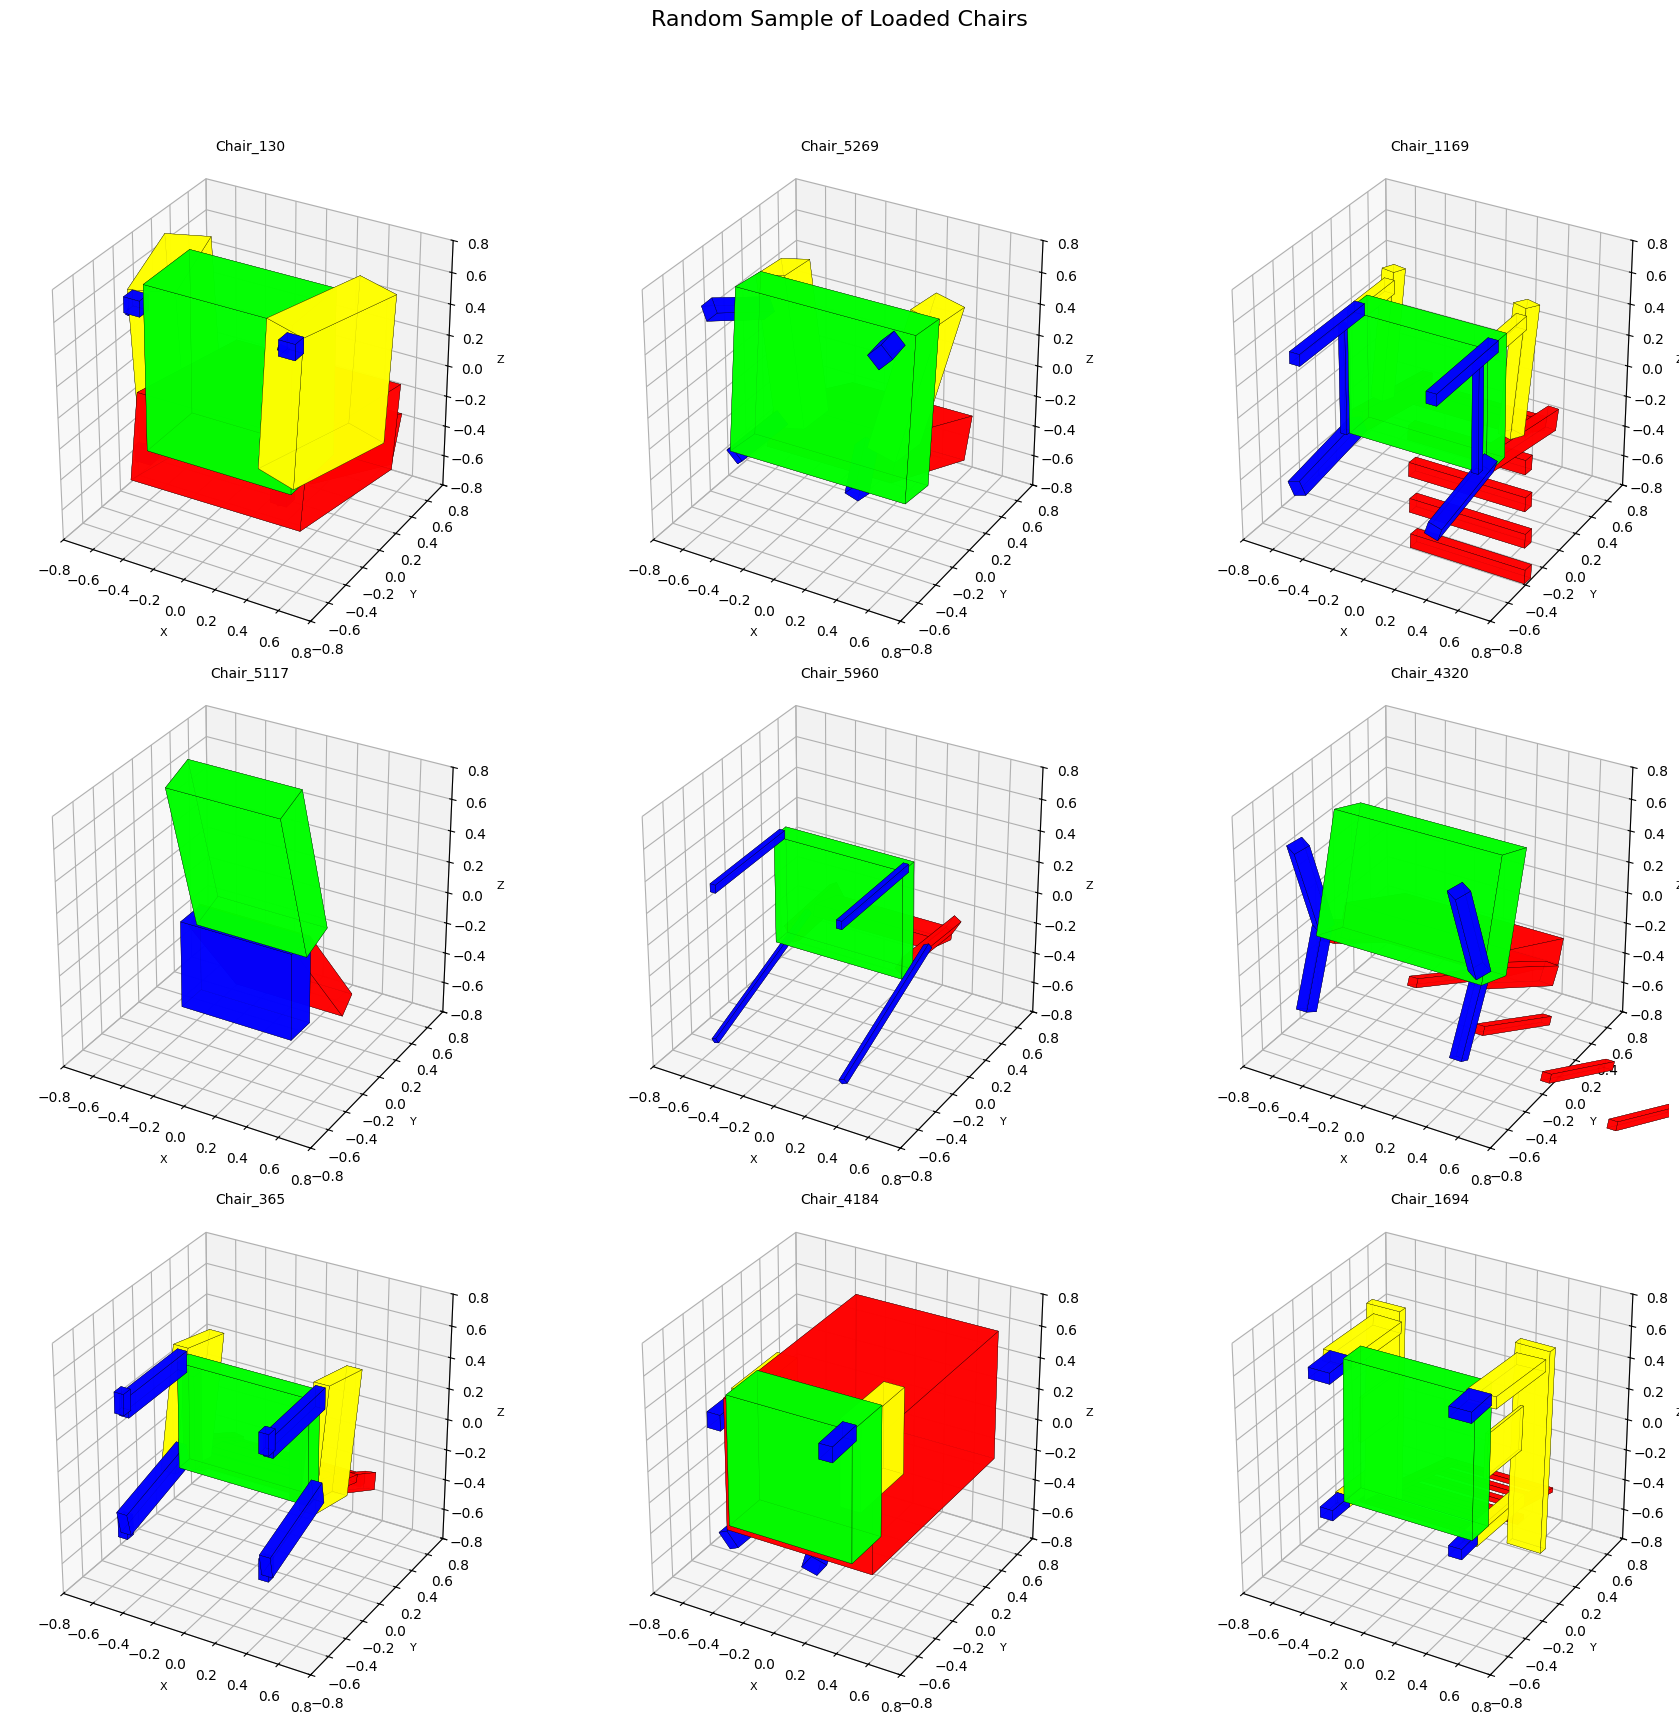

[SUCCESS] Grid plot displayed successfully.


In [9]:
## 4. Display Chairs (Sample)

if all_dsl_shapes:
    debug_info("Displaying a random 3x3 grid of loaded chairs...")
    
    # Get 9 random chairs
    num_to_sample = min(9, len(all_dsl_shapes))
    random_keys = random.sample(list(all_dsl_shapes.keys()), num_to_sample)
    
    dsl_list_for_grid = [all_dsl_shapes[key]['dsl'] for key in random_keys]
    name_list_for_grid = [key.replace('.json', '') for key in random_keys]
    
    # Plot the grid (will display inline in a notebook)
    plot_dsl_grid(
        dsl_list_for_grid,
        name_list_for_grid,
        save_path=None, # Set to None to display inline
        grid_cols=3,
        grid_title="Random Sample of Loaded Chairs"
    )
else:
    debug_error("No DSL shapes loaded, cannot display.")

In [10]:
## 5. Extract L1 Structures & Parameters

# This cell corresponds to cell [20] in your notebook
combined_singletons_detailed_pickle = saved_directory / "combined_singletons_detailed_L1.pkl"
combined_pairs_detailed_pickle = saved_directory / "combined_pairs_detailed_L1.pkl"

if combined_singletons_detailed_pickle.exists() and combined_pairs_detailed_pickle.exists():
    debug_info("Loading L1 detailed dictionaries from pickle...")
    with open(combined_singletons_detailed_pickle, "rb") as f:
        combined_singletons_detailed_L1 = pickle.load(f)
    with open(combined_pairs_detailed_pickle, "rb") as f:
        combined_pairs_detailed_L1 = pickle.load(f)
    debug_success("Loaded L1 detailed singleton and pair dictionaries.")
else:
    debug_info("Building L1 detailed dictionaries for singletons and pairs...")
    combined_singletons_detailed_L1 = {}
    combined_pairs_detailed_L1 = {}

    for filename, data in tqdm(all_dsl_shapes.items(), desc="Aggregating L1 Parameters"):
        # SINGLETON parameters
        for pattern_name, param_lists in data["singleton_params"].items():
            for param_list in param_lists or []:
                combined_singletons_detailed_L1.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })
        # PAIR parameters
        for pattern_name, param_lists in data["pair_params"].items():
            for param_list in param_lists or []:
                combined_pairs_detailed_L1.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })

    # Apply GMM Clustering
    # debug_info("\nApplying GMM Clustering to L1 'Rotate' pattern...")
    # combined_singletons_detailed_L1 = cluster_key_with_gmm(
    #     combined_singletons_detailed_L1, 'Rotate', max_clusters=8, verbose=True
    # )
    # debug_info("\nApplying GMM Clustering to L1 'Scale' pattern...")
    # combined_singletons_detailed_L1 = cluster_key_with_gmm(
    #     combined_singletons_detailed_L1, 'Scale', max_clusters=8, verbose=True
    # )
    
    # Save to pickle
    with open(combined_singletons_detailed_pickle, "wb") as f:
        pickle.dump(combined_singletons_detailed_L1, f)
    with open(combined_pairs_detailed_pickle, "wb") as f:
        pickle.dump(combined_pairs_detailed_L1, f)
    debug_success("Built, clustered, and saved L1 parameter structures.")

print(f"\nL1 Singleton Keys: {list(combined_singletons_detailed_L1.keys())}")
print(f"L1 Pair Keys: {list(combined_pairs_detailed_L1.keys())}")

[INFO] Loading L1 detailed dictionaries from pickle...
[SUCCESS] Loaded L1 detailed singleton and pair dictionaries.

L1 Singleton Keys: ['Rotate', 'Scale', 'Translate', 'SymRef', 'SymRot', 'SymTrans']
L1 Pair Keys: ['Rotate(Scale)', 'Scale(Box)', 'Translate(Rotate)', 'Union(Translate)', 'SymRef(Translate)', 'SymRef(Union)', 'Union(SymRef)', 'SymRot(Union)', 'Union(SymRot)', 'SymRot(Translate)', 'SymTrans(Translate)', 'Union(SymTrans)']


In [11]:
## 6. Prepare L1 Training Data

# This cell corresponds to cell [24] in your notebook
debug_info("--- Preparing L1 data for model training ---")

training_singleton_params_L1 = {}
for pattern_name, records in combined_singletons_detailed_L1.items():
    if records:
        training_singleton_params_L1[pattern_name] = [rec['params'] for rec in records]

training_pair_params_L1 = {}
for pattern_name, records in combined_pairs_detailed_L1.items():
    if records:
        training_pair_params_L1[pattern_name] = [rec['params'] for rec in records]

debug_success(f"L1 Data flattened for AE training.")
print(f"Found {len(training_singleton_params_L1)} L1 singleton patterns to train.")
print(f"Found {len(training_pair_params_L1)} L1 pair patterns to train.")

[INFO] --- Preparing L1 data for model training ---
[SUCCESS] L1 Data flattened for AE training.
Found 6 L1 singleton patterns to train.
Found 12 L1 pair patterns to train.


In [12]:
## 7. Train L1 PCA Models

# This cell is modified to train/load PCAModels, not Autoencoders.
# We also change saving/loading to use torch.save(model) and torch.load(model)
# to ensure the .data_mean_ and .data_std_ attributes are preserved.

models_exist_L1 = any(saved_models_L1_dir.glob('*.pth'))
singleton_models_L1 = {}
pair_models_L1 = {}

if models_exist_L1:
    debug_info(f"--- L1 PCA models found. Loading from {saved_models_L1_dir} ---")

    # Load L1 Singleton Models
    for name, params in training_singleton_params_L1.items():
        if not params: continue
        num_params = len(params[0])
        if num_params <= 1: continue
        
        save_file = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                # Load the entire model object to get components + stats
                model = torch.load(save_file, map_location=DEVICE)
                model.eval()
                singleton_models_L1[name] = model
                debug_success(f"Loaded L1 PCA singleton model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load L1 model '{name}': {e}")

    # Load L1 Pair Models
    for name, params in training_pair_params_L1.items():
        if not params: continue
        num_params = len(params[0])
        if num_params <= 1: continue
        
        save_file = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                # Load the entire model object
                model = torch.load(save_file, map_location=DEVICE)
                model.eval()
                pair_models_L1[name] = model
                debug_success(f"Loaded L1 PCA pair model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load L1 model '{name}': {e}")
else:
    debug_info("--- No L1 models found. Starting PCA fitting process... ---")

    debug_info("Fitting L1 singleton PCA models...")
    singleton_models_L1 = find_abstractions_pca(
        training_singleton_params_L1, 
        structure_type="SINGLETONS_L1_PCA", 
        min_examples=50, 
        retrain_iterations=1,
        error_threshold=0.01 # PCA error is different, may need tuning
    )

    debug_info("Fitting L1 pair PCA models...")
    pair_models_L1 = find_abstractions_pca(
        training_pair_params_L1, 
        structure_type="PAIRS_L1_PCA", 
        min_examples=50, 
        retrain_iterations=1,
        error_threshold=0.01
    )

    # Save L1 Models
    for name, model in singleton_models_L1.items():
        save_path = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        torch.save(model, save_path) # Save the entire model
    for name, model in pair_models_L1.items():
        save_path = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        torch.save(model, save_path) # Save the entire model
        
    debug_success(f"Saved L1 PCA models to {saved_models_L1_dir}")

debug_success(f"--- L1 Workflow complete. {len(singleton_models_L1)} singleton and {len(pair_models_L1)} pair PCA models are ready. ---")

[INFO] --- No L1 models found. Starting PCA fitting process... ---
[INFO] Fitting L1 singleton PCA models...
[INFO] Fitting PCA for Rotate (Iter 1) on 38858 samples...
[SUCCESS] PCA fit complete. Components shape: torch.Size([4, 3])
[INFO] [Rotate Iter 1] Kept 157/38858 examples.
[INFO] Fitting PCA for Scale (Iter 1) on 38858 samples...
[SUCCESS] PCA fit complete. Components shape: torch.Size([3, 2])
[INFO] [Scale Iter 1] Kept 804/38858 examples.
[INFO] Fitting PCA for Translate (Iter 1) on 38858 samples...
[SUCCESS] PCA fit complete. Components shape: torch.Size([3, 2])
[INFO] [Translate Iter 1] Kept 549/38858 examples.
[INFO] Fitting PCA for SymRef (Iter 1) on 11859 samples...
[SUCCESS] PCA fit complete. Components shape: torch.Size([6, 5])
[INFO] [SymRef Iter 1] Kept 5563/11859 examples.
[INFO] Fitting PCA for SymTrans (Iter 1) on 270 samples...
[SUCCESS] PCA fit complete. Components shape: torch.Size([3, 2])
[INFO] [SymTrans Iter 1] Kept 4/270 examples.
[INFO] Fitting PCA for SymRo

In [13]:
## 8. Integrate L1 Abstractions (Example)

# This cell corresponds to cell [32] in your notebook
if all_dsl_shapes and (singleton_models_L1 or pair_models_L1):
    debug_info("--- Testing L1 Abstraction Integration ---")

    # Pick a sample chair
    sample_key = "Chair_274.json" # Use a known complex chair
    if sample_key not in all_dsl_shapes:
        sample_key = list(all_dsl_shapes.keys())[0] # Fallback

    original_dsl = all_dsl_shapes[sample_key]["dsl"]

    # Run the integration
    abstracted_dsl_L1 = integrate_abstractions(
        original_dsl, 
        singleton_models_L1, 
        pair_models_L1, 
        error_threshold=0.01
    )

    print("\n--- ORIGINAL CHAIR DSL (L0) ---")
    print(original_dsl)

    print("\n--- ABSTRACTED CHAIR DSL (L1) ---")
    print(abstracted_dsl_L1)
else:
    debug_error("Cannot run integration: Missing DSL shapes or L1 models.")

[INFO] --- Testing L1 Abstraction Integration ---

--- ORIGINAL CHAIR DSL (L0) ---
Union(
    Union(
        Translate(center=[-0.014, 0.046, 0.125])
            Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                Scale(lengths=[0.862, 0.082, 0.679])
                    Box(label=1),
        Union(
            Translate(center=[-0.013, -0.386, -0.227])
                Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                    Scale(lengths=[0.773, 0.085, 0.052])
                        Box(label=2),
            SymRef(
                plane=[1.000, 0.007, 0.000],
                point_on_plane=[-0.014, -0.357, 0.436]
            )(
                Union(
                    Translate(center=[-0.419, -0.360, 0.436])
                        Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                            Scale(lengths=[0.052, 0.861, 0.060])
                                Box(label=2),
                    Union(
                        Translate(center=[-0.413, 

In [14]:
## 13. Create New Dataset with L1 Abstractions

debug_info("--- Creating new L1 Abstracted Dataset ---")
all_abstracted_shapes_L1 = {}
pickle_file_L1 = saved_directory / "all_abstracted_shapes_L1.pkl"

if pickle_file_L1.exists():
    debug_info(f"Loading L1 abstracted shapes from pickle: {pickle_file_L1}")
    with open(pickle_file_L1, "rb") as f:
        all_abstracted_shapes_L1 = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L1)} L1 abstracted shapes.")
else:
    if all_dsl_shapes and (singleton_models_L1 or pair_models_L1):
        for filename, data in tqdm(all_dsl_shapes.items(), desc="Integrating L1 Abstractions"):
            abstracted_dsl = integrate_abstractions(
                data["dsl"],
                singleton_models_L1,
                pair_models_L1,
                error_threshold=0.01
            )
            # We must also collect the parameters for the new abstracted tree
            l1_singletons, l1_pairs = collect_singleton_and_pair_data([abstracted_dsl])

            all_abstracted_shapes_L1[filename] = {
                "dsl": abstracted_dsl,
                "singleton_params": l1_singletons,
                "pair_params": l1_pairs,
                "original_dsl": data["dsl"] # Keep a reference
            }

        # Save the new dataset
        with open(pickle_file_L1, "wb") as f:
            pickle.dump(all_abstracted_shapes_L1, f)
        debug_success(f"Created and saved {len(all_abstracted_shapes_L1)} L1 abstracted shapes to {pickle_file_L1}")
    else:
        debug_error("Cannot create L1 abstracted dataset: Missing original DSL shapes or L1 models.")

# Display a sample from the new dataset
if all_abstracted_shapes_L1:
    sample_key = list(all_abstracted_shapes_L1.keys())[0]
    print(f"\nSample L1 abstracted shape '{sample_key}' keys: {all_abstracted_shapes_L1[sample_key].keys()}")
    print("\nSample L1 Singleton Params (should include 'Abstraction' nodes):")
    print(all_abstracted_shapes_L1[sample_key]['singleton_params'].keys())

[INFO] --- Creating new L1 Abstracted Dataset ---


Integrating L1 Abstractions:   0%|          | 0/6201 [00:00<?, ?it/s]

[SUCCESS] Created and saved 6201 L1 abstracted shapes to c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\all_abstracted_shapes_L1.pkl

Sample L1 abstracted shape 'Chair_1.json' keys: dict_keys(['dsl', 'singleton_params', 'pair_params', 'original_dsl'])

Sample L1 Singleton Params (should include 'Abstraction' nodes):
dict_keys(['Rotate', 'Scale', 'Translate'])


In [15]:
## 15. Run Abstraction Pipeline Again (L2)

# Check if we have the L1 abstracted dataset
if not all_abstracted_shapes_L1:
    debug_error("Cannot start L2 pipeline: 'all_abstracted_shapes_L1' is empty.")
else:
    debug_info("--- Starting Hierarchical Abstraction Pipeline (L2) ---")

    # --- 15a. Extract L2 Structures & Parameters ---
    debug_info("--- 15a. Extracting L2 Structures & Parameters ---")
    combined_singletons_detailed_L2 = {}
    combined_pairs_detailed_L2 = {}

    for filename, data in tqdm(all_abstracted_shapes_L1.items(), desc="Aggregating L2 Parameters"):
        # Parameters were already collected when creating the L1 dataset
        # We just need to aggregate them in the 'detailed' format
        for pattern_name, param_lists in data["singleton_params"].items():
            for param_list in param_lists or []:
                combined_singletons_detailed_L2.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })
        for pattern_name, param_lists in data["pair_params"].items():
            for param_list in param_lists or []:
                combined_pairs_detailed_L2.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })

    debug_success("Aggregated L2 parameters.")
    print(f"\nL2 Singleton Keys: {list(combined_singletons_detailed_L2.keys())}")
    print(f"L2 Pair Keys: {list(combined_pairs_detailed_L2.keys())}")

    # --- 15b. Prepare L2 Training Data ---
    debug_info("--- 15b. Preparing L2 Training Data ---")
    training_singleton_params_L2 = {}
    for pattern_name, records in combined_singletons_detailed_L2.items():
        if records:
            training_singleton_params_L2[pattern_name] = [rec['params'] for rec in records]

    training_pair_params_L2 = {}
    for pattern_name, records in combined_pairs_detailed_L2.items():
        if records:
            training_pair_params_L2[pattern_name] = [rec['params'] for rec in records]

    debug_success(f"L2 Data flattened for training.")
    print(f"Found {len(training_singleton_params_L2)} L2 singleton patterns to train.")
    print(f"Found {len(training_pair_params_L2)} L2 pair patterns to train.")

    # --- 15c. Train L2 PCA Models ---
    debug_info("--- 15c. Loading or Fitting L2 PCA Models ---")
    
    models_exist_L2 = any(saved_models_L2_dir.glob('*.pth'))
    singleton_models_L2 = {}
    pair_models_L2 = {}

    if models_exist_L2:
        debug_info(f"--- L2 models found. Loading from {saved_models_L2_dir} ---")

        # Load L2 Singleton Models
        for name, params in training_singleton_params_L2.items():
            if not params: continue
            num_params = len(params[0])
            if num_params <= 1: continue
            save_file = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            if save_file.is_file():
                try:
                    model = torch.load(save_file, map_location=DEVICE)
                    model.eval()
                    singleton_models_L2[name] = model
                    debug_success(f"Loaded L2 PCA singleton model for '{name}'")
                except Exception as e:
                    debug_error(f"Failed to load L2 model '{name}': {e}")

        # Load L2 Pair Models
        for name, params in training_pair_params_L2.items():
            if not params: continue
            num_params = len(params[0])
            if num_params <= 1: continue
            save_file = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            if save_file.is_file():
                try:
                    model = torch.load(save_file, map_location=DEVICE)
                    model.eval()
                    pair_models_L2[name] = model
                    debug_success(f"Loaded L2 PCA pair model for '{name}'")
                except Exception as e:
                    debug_error(f"Failed to load L2 model '{name}': {e}")

    else:
        debug_info("--- No L2 models found. Starting PCA fitting process... ---")

        debug_info("Fitting L2 singleton PCA models...")
        singleton_models_L2 = find_abstractions_pca(
            training_singleton_params_L2, 
            structure_type="SINGLETONS_L2_PCA", 
            min_examples=50,
            error_threshold=0.01
        )

        debug_info("Fitting L2 pair PCA models...")
        pair_models_L2 = find_abstractions_pca(
            training_pair_params_L2, 
            structure_type="PAIRS_L2_PCA", 
            min_examples=50,
            error_threshold=0.01
        )

        # Save L2 Models
        for name, model in singleton_models_L2.items():
            save_path = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            torch.save(model, save_path)
        for name, model in pair_models_L2.items():
            save_path = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            torch.save(model, save_path)
        debug_success(f"Saved L2 PCA models to {saved_models_L2_dir}")

    debug_success(f"--- L2 Workflow complete. {len(singleton_models_L2)} L2 singleton and {len(pair_models_L2)} L2 pair models are ready. ---")

    # --- 15d. Integrate L2 Abstractions (Example) ---
    debug_info("--- 15d. Testing L2 Abstraction Integration ---")

    sample_key = "Chair_274.json"
    if sample_key not in all_abstracted_shapes_L1:
        sample_key = list(all_abstracted_shapes_L1.keys())[0]

    dsl_L1 = all_abstracted_shapes_L1[sample_key]["dsl"]

    # Run integration using L2 models on the L1-abstracted tree
    abstracted_dsl_L2 = integrate_abstractions(
        dsl_L1, 
        singleton_models_L2, 
        pair_models_L2, 
        error_threshold=0.01
    )

    print(f"\n--- ABSTRACTED CHAIR DSL (L1) ---")
    print(dsl_L1)

    print(f"\n--- HIERARCHICAL ABSTRACTED CHAIR DSL (L2) ---")
    print(abstracted_dsl_L2)

    debug_info("Hierarchical abstraction pipeline finished.")

[INFO] --- Starting Hierarchical Abstraction Pipeline (L2) ---
[INFO] --- 15a. Extracting L2 Structures & Parameters ---


Aggregating L2 Parameters:   0%|          | 0/6201 [00:00<?, ?it/s]

[SUCCESS] Aggregated L2 parameters.

L2 Singleton Keys: ['Rotate', 'Scale', 'Translate', 'Abs(SymRef(Translate))', 'SymRef', 'Abs(SymRef(Union))', 'Abs(Rotate)', 'Abs(SymRef)', 'Abs(Rotate(Scale))', 'Abs(Translate(Rotate))', 'SymRot', 'Abs(Scale(Box))', 'Abs(Translate)', 'SymTrans', 'Abs(SymRot(Union))', 'Abs(SymRot(Translate))', 'Abs(SymTrans(Translate))', 'Abs(SymTrans)', 'Abs(SymRot)']
L2 Pair Keys: ['Rotate(Scale)', 'Scale(Box)', 'Translate(Rotate)', 'Union(Translate)', 'Abs(SymRef(Translate))(Rotate)', 'SymRef(Union)', 'Union(Abs(SymRef(Translate)))', 'Union(SymRef)', 'Abs(SymRef(Union))(Translate)', 'Union(Abs(SymRef(Union)))', 'Abs(Rotate)(Scale)', 'Translate(Abs(Rotate))', 'Abs(SymRef)(Union)', 'SymRef(Translate)', 'Union(Abs(SymRef))', 'Abs(Rotate(Scale))(Box)', 'Abs(SymRef(Union))(Union)', 'Translate(Abs(Rotate(Scale)))', 'Abs(Translate(Rotate))(Scale)', 'SymRot(Union)', 'Union(Abs(Translate(Rotate)))', 'Union(SymRot)', 'Abs(SymRef(Union))(Abs(Translate(Rotate)))', 'Rotate(Ab

In [17]:
## 20. Create New Dataset with L2 Abstractions

debug_info("--- Creating new L2 Abstracted Dataset ---")
all_abstracted_shapes_L2 = {}
pickle_file_L2 = saved_directory / "all_abstracted_shapes_L2.pkl"

if pickle_file_L2.exists():
    debug_info(f"Loading L2 abstracted shapes from pickle: {pickle_file_L2}")
    with open(pickle_file_L2, "rb") as f:
        all_abstracted_shapes_L2 = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L2)} L2 abstracted shapes.")
else:
    if all_abstracted_shapes_L1 and (singleton_models_L2 or pair_models_L2):
        debug_info("Generating L2 dataset from L1 dataset...")
        for filename, data in tqdm(all_abstracted_shapes_L1.items(), desc="Integrating L2 Abstractions"):
            # Get the L1 abstracted DSL
            dsl_L1 = data["dsl"]

            # Integrate L2 abstractions on top of L1 abstractions
            abstracted_dsl_L2 = integrate_abstractions(
                dsl_L1,
                singleton_models_L2,
                pair_models_L2,
                error_threshold=0.1,
                # detailed_debug=True
            )

            # Collect parameters from the new L2-abstracted tree
            l2_singletons, l2_pairs = collect_singleton_and_pair_data([abstracted_dsl_L2])

            all_abstracted_shapes_L2[filename] = {
                "dsl": abstracted_dsl_L2,
                "singleton_params": l2_singletons,
                "pair_params": l2_pairs,
                "original_dsl": data["original_dsl"] # Pass original reference
            }

        # Save the new L2 dataset
        with open(pickle_file_L2, "wb") as f:
            pickle.dump(all_abstracted_shapes_L2, f)
        debug_success(f"Created and saved {len(all_abstracted_shapes_L2)} L2 abstracted shapes to {pickle_file_L2}")
    else:
        debug_error("Cannot create L2 abstracted dataset: Missing L1 shapes or L2 models.")

# # Display a sample from the new L2 dataset
# if all_abstracted_shapes_L2:
#     sample_key = list(all_abstracted_shapes_L2.keys())[0]
#     print(f"\nSample L2 abstracted shape '{sample_key}' keys: {all_abstracted_shapes_L2[sample_key].keys()}")
#     print("\nSample L2 Singleton Params (should include 'Abs(Abs(...))' patterns):")
#     print(list(all_abstracted_shapes_L2[sample_key]['singleton_params'].keys()))

#     print("\n--- L2 Example ---")
#     print(all_abstracted_shapes_L2[sample_key]['dsl'])

[INFO] --- Creating new L2 Abstracted Dataset ---
[INFO] Generating L2 dataset from L1 dataset...


Integrating L2 Abstractions:   0%|          | 0/6201 [00:00<?, ?it/s]

[SUCCESS] Created and saved 6201 L2 abstracted shapes to c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\all_abstracted_shapes_L2.pkl


In [18]:
## 25. Test Expansion (Combined)
# (This was your cell [25])
from abstractionssymh.abstraction_utils import expand_l1_to_l0, expand_l2_to_l1

print("--- ORIGINAL L0 ---")
print(all_dsl_shapes["Chair_1.json"]["dsl"])

print("\n--- L1 EXPANDED TO L0 ---")
print(expand_l1_to_l0(all_abstracted_shapes_L1["Chair_1.json"]["dsl"], singleton_models_L1, pair_models_L1))

print("\n--- L2 EXPANDED TO L0 ---")
print(expand_l1_to_l0(expand_l2_to_l1(all_abstracted_shapes_L2["Chair_1.json"]["dsl"], singleton_models_L1, pair_models_L1, singleton_models_L2, pair_models_L2), singleton_models_L1, pair_models_L1))

--- ORIGINAL L0 ---
Union(
    Union(
        Translate(center=[0.003, 0.149, 0.072])
            Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                Scale(lengths=[0.891, 0.224, 0.806])
                    Box(label=1),
        Translate(center=[0.004, -0.422, 0.170])
            Rotate(quat=[-0.3389, -0.0000, 0.0065, 0.9408])
                Scale(lengths=[0.898, 0.524, 1.154])
                    Box(label=2)
    ),
    Translate(center=[0.030, 0.488, -0.315])
        Rotate(quat=[-0.0821, -0.0071, -0.0494, 0.9954])
            Scale(lengths=[0.892, 0.781, 0.305])
                Box(label=0)
)

--- L1 EXPANDED TO L0 ---
[INFO] Starting L1 to L0 expansion...
[SUCCESS] L1 to L0 expansion completed
Union(
    Union(
        Translate(center=[0.003, 0.149, 0.072])
            Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                Scale(lengths=[0.891, 0.224, 0.806])
                    Box(label=1),
        Translate(center=[0.004, -0.422, 0.170])
            Rotate(qu

In [19]:
## 26. Comparative Analysis of Abstraction Levels (All Chairs)
# (This was your cell [26])

def analyze_single_tree(node):
    """Analyze a single DSL tree and return statistics"""
    if node is None:
        return {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}}

    def _traverse_count(node, counts):
        """Recursive traversal to count nodes"""
        if not hasattr(node, "serialize") and not isinstance(node, Abstraction):
            return

        # Count the current node
        node_type = type(node).__name__
        if isinstance(node, Abstraction):
            node_type = f"Abs({node.pattern_name})"
            counts['abstraction_nodes'] += 1
            counts['unique_patterns'].add(node.pattern_name)
        else:
            counts['total_nodes'] += 1

        # Count in breakdown
        counts['node_breakdown'][node_type] = counts['node_breakdown'].get(node_type, 0) + 1

        # Get children
        if isinstance(node, Abstraction):
            children = node.children
        elif hasattr(node, "serialize"):
            _, (_, children) = node.serialize()
        else:
            children = []

        # Recursively count children
        for child in children:
            if hasattr(child, "serialize") or isinstance(child, Abstraction):
                _traverse_count(child, counts)

    counts = {
        'total_nodes': 0,
        'abstraction_nodes': 0,
        'unique_patterns': set(),
        'node_breakdown': {}
    }
    _traverse_count(node, counts)

    return counts

def analyze_abstraction_levels_all_chairs():
    """Comprehensive analysis comparing L0, L1, and L2 for ALL chairs"""

    print("=" * 80)
    print("COMPREHENSIVE PCA ABSTRACTION ANALYSIS - ALL CHAIRS") # <-- Title updated
    print(f"Dataset Size: {len(all_dsl_shapes)} chairs")
    print("=" * 80)

    # Overall statistics
    total_stats = {
        'L0': {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}},
        'L1': {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}},
        'L2': {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}}
    }

    # Progress bar for analysis
    from tqdm.auto import tqdm

    # Analyze all chairs
    for chair_id in tqdm(all_dsl_shapes.keys(), desc="Analyzing all chairs"):
        try:
            # Analyze each level
            l0_stats = analyze_single_tree(all_dsl_shapes[chair_id]["dsl"])
            l1_stats = analyze_single_tree(all_abstracted_shapes_L1[chair_id]["dsl"])
            l2_stats = analyze_single_tree(all_abstracted_shapes_L2[chair_id]["dsl"])

            # Aggregate totals
            for level_stats, level_key in zip([l0_stats, l1_stats, l2_stats], ['L0', 'L1', 'L2']):
                total_stats[level_key]['total_nodes'] += level_stats['total_nodes']
                total_stats[level_key]['abstraction_nodes'] += level_stats['abstraction_nodes']
                total_stats[level_key]['unique_patterns'].update(level_stats['unique_patterns'])

                # Aggregate node breakdown
                for node_type, count in level_stats['node_breakdown'].items():
                    total_stats[level_key]['node_breakdown'][node_type] = \
                        total_stats[level_key]['node_breakdown'].get(node_type, 0) + count

        except Exception as e:
            print(f"Error analyzing chair {chair_id}: {e}")
            continue

    # Calculate averages and percentages
    num_chairs = len(all_dsl_shapes)
    analysis_results = {}

    for level in ['L0', 'L1', 'L2']:
        stats = total_stats[level]
        analysis_results[level] = {
            'total_nodes': stats['total_nodes'],
            'avg_nodes_per_chair': stats['total_nodes'] / num_chairs,
            'abstraction_nodes': stats['abstraction_nodes'],
            'avg_abstraction_nodes_per_chair': stats['abstraction_nodes'] / num_chairs,
            'unique_patterns': len(stats['unique_patterns']),
            'unique_patterns_list': sorted(list(stats['unique_patterns'])),
            'node_breakdown': dict(sorted(stats['node_breakdown'].items(), 
                                           key=lambda x: x[1], reverse=True)),
            'abstraction_ratio': stats['abstraction_nodes'] / stats['total_nodes'] if stats['total_nodes'] > 0 else 0
        }

    # Calculate reduction percentages
    analysis_results['L1']['node_reduction_vs_L0'] = (
        (analysis_results['L0']['total_nodes'] - analysis_results['L1']['total_nodes']) / 
        analysis_results['L0']['total_nodes'] * 100
    )
    analysis_results['L2']['node_reduction_vs_L0'] = (
        (analysis_results['L0']['total_nodes'] - analysis_results['L2']['total_nodes']) / 
        analysis_results['L0']['total_nodes'] * 100
    )
    analysis_results['L2']['node_reduction_vs_L1'] = (
        (analysis_results['L1']['total_nodes'] - analysis_results['L2']['total_nodes']) / 
        analysis_results['L1']['total_nodes'] * 100
    )

    return analysis_results

# Run the analysis
analysis_results = analyze_abstraction_levels_all_chairs()

# Display results in a comprehensive format
print("\n" + "=" * 80)
print("SUMMARY STATISTICS - ALL CHAIRS (PCA)")
print("=" * 80)

print(f"\nDATASET OVERVIEW:")
print(f"   • Total chairs analyzed: {len(all_dsl_shapes)}")
print(f"   • L0 (Original): {analysis_results['L0']['total_nodes']:,} total nodes")
print(f"   • L1 (Abstracted): {analysis_results['L1']['total_nodes']:,} total nodes")
print(f"   • L2 (Hierarchical): {analysis_results['L2']['total_nodes']:,} total nodes")

print(f"\nNODE COUNT REDUCTION:")
print(f"   • L1 vs L0: {analysis_results['L1']['node_reduction_vs_L0']:.1f}% reduction")
print(f"   • L2 vs L0: {analysis_results['L2']['node_reduction_vs_L0']:.1f}% reduction")
print(f"   • L2 vs L1: {analysis_results['L2']['node_reduction_vs_L1']:.1f}% reduction")

print(f"\nABSTRACTION NODES:")
print(f"   • L0: {analysis_results['L0']['abstraction_nodes']:,} abstraction nodes")
print(f"   • L1: {analysis_results['L1']['abstraction_nodes']:,} abstraction nodes")
print(f"   • L2: {analysis_results['L2']['abstraction_nodes']:,} abstraction nodes")

print(f"\nABSTRACTION RATIO (Abstraction Nodes / Total Nodes):")
print(f"   • L0: {analysis_results['L0']['abstraction_ratio']:.1%}")
print(f"   • L1: {analysis_results['L1']['abstraction_ratio']:.1%}")
print(f"   • L2: {analysis_results['L2']['abstraction_ratio']:.1%}")

print(f"\nUNIQUE PATTERN TYPES:")
print(f"   • L0: {analysis_results['L0']['unique_patterns']} patterns")
print(f"   • L1: {analysis_results['L1']['unique_patterns']} patterns")
print(f"   • L2: {analysis_results['L2']['unique_patterns']} patterns")

print(f"\nL1 UNIQUE ABSTRACTION PATTERNS:")
for i, pattern in enumerate(analysis_results['L1']['unique_patterns_list'], 1):
    print(f"   {i:2d}. {pattern}")

print(f"\nL2 UNIQUE ABSTRACTION PATTERNS:")
for i, pattern in enumerate(analysis_results['L2']['unique_patterns_list'], 1):
    print(f"   {i:2d}. {pattern}")

print(f"\nAVERAGE NODES PER CHAIR:")
print(f"   • L0: {analysis_results['L0']['avg_nodes_per_chair']:.1f} nodes/chair")
print(f"   • L1: {analysis_results['L1']['avg_nodes_per_chair']:.1f} nodes/chair")
print(f"   • L2: {analysis_results['L2']['avg_nodes_per_chair']:.1f} nodes/chair")

print(f"\nAVERAGE ABSTRACTION NODES PER CHAIR:")
print(f"   • L0: {analysis_results['L0']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")
print(f"   • L1: {analysis_results['L1']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")
print(f"   • L2: {analysis_results['L2']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")

# Display top node types for each level
for level in ['L0', 'L1', 'L2']:
    print(f"\n{level} - TOP 10 NODE TYPES:")
    node_breakdown = analysis_results[level]['node_breakdown']
    top_nodes = list(node_breakdown.items())[:10]
    for node_type, count in top_nodes:
        percentage = (count / (analysis_results[level]['total_nodes'] + analysis_results[level]['abstraction_nodes'])) * 100
        print(f"   • {node_type:<25} {count:>6,} ({percentage:5.1f}%)")

COMPREHENSIVE PCA ABSTRACTION ANALYSIS - ALL CHAIRS
Dataset Size: 6201 chairs


Analyzing all chairs:   0%|          | 0/6201 [00:00<?, ?it/s]


SUMMARY STATISTICS - ALL CHAIRS (PCA)

DATASET OVERVIEW:
   • Total chairs analyzed: 6201
   • L0 (Original): 200,411 total nodes
   • L1 (Abstracted): 175,540 total nodes
   • L2 (Hierarchical): 138,010 total nodes

NODE COUNT REDUCTION:
   • L1 vs L0: 12.4% reduction
   • L2 vs L0: 31.1% reduction
   • L2 vs L1: 21.4% reduction

ABSTRACTION NODES:
   • L0: 0 abstraction nodes
   • L1: 13,638 abstraction nodes
   • L2: 33,381 abstraction nodes

ABSTRACTION RATIO (Abstraction Nodes / Total Nodes):
   • L0: 0.0%
   • L1: 7.8%
   • L2: 24.2%

UNIQUE PATTERN TYPES:
   • L0: 0 patterns
   • L1: 16 patterns
   • L2: 16 patterns

L1 UNIQUE ABSTRACTION PATTERNS:
    1. Rotate
    2. Rotate(Abs(Scale(Box)))
    3. Rotate(Scale)
    4. Scale(Box)
    5. SymRef
    6. SymRef(Translate)
    7. SymRef(Union)
    8. SymRot
    9. SymRot(Translate)
   10. SymRot(Union)
   11. SymTrans
   12. SymTrans(Translate)
   13. Translate
   14. Translate(Abs(Rotate(Scale)))
   15. Translate(Abs(Rotate))
   1

In [20]:
## 28. Visual Comparison: Plot Expanded Original vs L1 vs L2 for Sample Chairs
# (This was your cell [28])

def plot_expanded_abstraction_comparison(num_chairs=10):
    """
    Plot expanded versions of Original (L0), L1 Abstracted, and L2 Abstracted
    after decompressing them back to L0 using the expansion functions
    """
    from abstractionssymh.plot_utils import plot_dsl_with_k3d

    print(f"Generating expanded abstraction comparison for {num_chairs} random chairs...")

    # Sample random chairs
    # sample_keys = random.sample(list(all_dsl_shapes.keys()), min(num_chairs, len(all_dsl_shapes)))

    sample_keys = ["Chair_5689.json"]

    for i, chair_key in enumerate(sample_keys):
        print(f"\n--- Chair {i+1}: {chair_key} ---")

        try:
            # Print here are all the dsls
            print("ORIGINAL DSL")
            print(all_dsl_shapes[chair_key]["dsl"])

            print("L1 to L0 DSL")
            print(all_abstracted_shapes_L1[chair_key]["dsl"])

            print("L2 DSL")
            print(all_abstracted_shapes_L2[chair_key]["dsl"])

            # Get all three versions and expand them to L0
            original_dsl = all_dsl_shapes[chair_key]["dsl"]

            # Expand L1 abstracted tree back to L0
            l1_expanded = expand_l1_to_l0(
                all_abstracted_shapes_L1[chair_key]["dsl"], 
                singleton_models_L1, 
                pair_models_L1
            )

            # Expand L2 abstracted tree back to L0 (through L1 then L0)
            l2_to_l1 = expand_l2_to_l1(
                all_abstracted_shapes_L2[chair_key]["dsl"],
                singleton_models_L1,
                pair_models_L1,
                singleton_models_L2,
                pair_models_L2
            )
            l2_expanded = expand_l1_to_l0(l2_to_l1, singleton_models_L1, pair_models_L1)

            # Print tree statistics
            l0_stats = analyze_single_tree(original_dsl)
            l1_abstracted_stats = analyze_single_tree(all_abstracted_shapes_L1[chair_key]["dsl"])
            l2_abstracted_stats = analyze_single_tree(all_abstracted_shapes_L2[chair_key]["dsl"])
            l1_expanded_stats = analyze_single_tree(l1_expanded)
            l2_expanded_stats = analyze_single_tree(l2_expanded)

            print("TREE STATISTICS:")
            print(f"ORIGINAL (L0): {l0_stats['total_nodes']} total nodes, {l0_stats['abstraction_nodes']} abstraction nodes")
            print(f"L1 ABSTRACTED: {l1_abstracted_stats['total_nodes']} total nodes, {l1_abstracted_stats['abstraction_nodes']} abstraction nodes")
            print(f"L2 ABSTRACTED: {l2_abstracted_stats['total_nodes']} total nodes, {l2_abstracted_stats['abstraction_nodes']} abstraction nodes")
            print(f"L1 EXPANDED: {l1_expanded_stats['total_nodes']} total nodes, {l1_expanded_stats['abstraction_nodes']} abstraction nodes")
            print(f"L2 EXPANDED: {l2_expanded_stats['total_nodes']} total nodes, {l2_expanded_stats['abstraction_nodes']} abstraction nodes")

            # Show abstraction patterns
            if l1_abstracted_stats['unique_patterns']:
                print(f"L1 Patterns: {', '.join(sorted(l1_abstracted_stats['unique_patterns']))}")
            if l2_abstracted_stats['unique_patterns']:
                print(f"L2 Patterns: {', '.join(sorted(l2_abstracted_stats['unique_patterns']))}")

            # Plot Original (L0)
            print("\nPLOTTING ORIGINAL (L0):")
            plot_dsl_with_k3d(original_dsl, save_path=None)

            # Plot L1 Expanded
            print("\nPLOTTING L1 ABSTRACTED -> EXPANDED:")
            plot_dsl_with_k3d(l1_expanded, save_path=None)

            # Plot L2 Expanded  
            print("\nPLOTTING L2 ABSTRACTED -> EXPANDED:")
            plot_dsl_with_k3d(l2_expanded, save_path=None)

            # Verify they produce the same geometry
            from abstractionssymh.abstraction_compare_utils import get_point_cloud_from_dsl, calculate_chamfer_distance

            pc_original = get_point_cloud_from_dsl(original_dsl, points_per_box=500)
            pc_l1_expanded = get_point_cloud_from_dsl(l1_expanded, points_per_box=500)
            pc_l2_expanded = get_point_cloud_from_dsl(l2_expanded, points_per_box=500)

            chamfer_l1 = calculate_chamfer_distance(pc_original, pc_l1_expanded)
            chamfer_l2 = calculate_chamfer_distance(pc_original, pc_l2_expanded)

            print(f"\nGEOMETRIC VERIFICATION:")
            print(f"Chamfer distance L1 Expanded vs Original: {chamfer_l1:.6f}")
            print(f"Chamfer distance L2 Expanded vs Original: {chamfer_l2:.6f}")

            # if chamfer_l1 < 0.001 and chamfer_l2 < 0.001:
            #     print("SUCCESS: All expanded versions produce identical geometry!")
            # else:
            #     print("WARNING: Some geometric differences detected")

            print("-" * 80)

        except Exception as e:
            print(f"Error processing chair {chair_key}: {e}")
            continue

# Run the comparison
plot_expanded_abstraction_comparison(1)

Generating expanded abstraction comparison for 1 random chairs...

--- Chair 1: Chair_5689.json ---
ORIGINAL DSL
Union(
    Union(
        Translate(center=[-0.014, -0.055, 0.125])
            Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                Scale(lengths=[0.916, 0.304, 1.099])
                    Box(label=1),
        SymRef(
            plane=[1.000, -0.008, 0.011],
            point_on_plane=[-0.007, -0.281, -0.275]
        )(
            Union(
                Translate(center=[-0.340, -0.279, -0.279])
                    Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                        Scale(lengths=[0.264, 0.717, 0.291])
                            Box(label=2),
                Translate(center=[-0.352, -0.409, 0.560])
                    Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
                        Scale(lengths=[0.241, 0.457, 0.229])
                            Box(label=2)
            )
        )
    ),
    Translate(center=[-0.014, 0.452, -0.280])
   

Output()

[SUCCESS] 3D plot displayed successfully.

PLOTTING L1 ABSTRACTED -> EXPANDED:
[INFO] Expanding DSL tree for visualization...
[INFO] Found 6 total boxes after expansion.


Output()

[SUCCESS] 3D plot displayed successfully.

PLOTTING L2 ABSTRACTED -> EXPANDED:
[INFO] Expanding DSL tree for visualization...
[INFO] Found 6 total boxes after expansion.


Output()

[SUCCESS] 3D plot displayed successfully.

GEOMETRIC VERIFICATION:
Chamfer distance L1 Expanded vs Original: 0.002411
Chamfer distance L2 Expanded vs Original: 0.002374
--------------------------------------------------------------------------------


In [ ]:
# In[7]:
## 7. Train L1 Autoencoders

# This cell corresponds to cell [27] in your notebook
models_exist_L1 = any(saved_models_L1_dir.glob('*.pth'))
singleton_models_L1 = {}
pair_models_L1 = {}

if models_exist_L1:
    debug_info(f"--- L1 models found. Loading from {saved_models_L1_dir} ---")
    
    # Load L1 Singleton Models
    for name, params in training_singleton_params_L1.items():
        if not params: continue
        num_params = len(params[0])
        if num_params <= 1: continue
        # --- FIX: Add suffix="pth" ---
        save_file = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                model.load_state_dict(torch.load(save_file, map_location=DEVICE))
                model.eval()
                singleton_models_L1[name] = model
                debug_success(f"Loaded L1 singleton model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load L1 model '{name}': {e}")
                
    # Load L1 Pair Models
    for name, params in training_pair_params_L1.items():
        if not params: continue
        num_params = len(params[0])
        if num_params <= 1: continue
        # --- FIX: Add suffix="pth" ---
        save_file = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                model.load_state_dict(torch.load(save_file, map_location=DEVICE))
                model.eval()
                pair_models_L1[name] = model
                debug_success(f"Loaded L1 pair model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load L1 model '{name}': {e}")
else:
    debug_info("--- No L1 models found. Starting training process... ---")
    
    debug_info("Training L1 singleton models...")
    # singleton_models_L1 = find_abstractions(
    #     training_singleton_params_L1, 
    #     structure_type="SINGLETONS_L1", 
    #     min_examples=50, 
    #     epochs=20
    # )

    # debug_info("Training L1 pair models...")
    # pair_models_L1 = find_abstractions(
    #     training_pair_params_L1, 
    #     structure_type="PAIRS_L1", 
    #     min_examples=50, 
    #     epochs=20
    # )
    singleton_models_L1 = find_abstractions_pca(
        training_singleton_params_L1, 
        structure_type="SINGLETONS_L1_PCA", 
        min_examples=50,
        retrain_iterations=1
    )
    pair_models_L1 = find_abstractions_pca(
        training_pair_params_L1, 
        structure_type="PAIRS_L1_PCA", 
        min_examples=50,
        retrain_iterations=1
    )

    # Save L1 Models
    for name, model in singleton_models_L1.items():
        # --- FIX: Add suffix="pth" ---
        save_path = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        torch.save(model.state_dict(), save_path)
    for name, model in pair_models_L1.items():
        # --- FIX: Add suffix="pth" ---
        save_path = saved_models_L1_dir / make_safe_filename(name, suffix="pth")
        torch.save(model.state_dict(), save_path)
    debug_success(f"Saved L1 models to {saved_models_L1_dir}")

debug_success(f"--- L1 Workflow complete. {len(singleton_models_L1)} singleton and {len(pair_models_L1)} pair models are ready. ---")

In [ ]:
## 8. Integrate L1 Abstractions (Example)

# This cell corresponds to cell [32] in your notebook
if all_dsl_shapes and (singleton_models_L1 or pair_models_L1):
    debug_info("--- Testing L1 Abstraction Integration ---")
    
    # Pick a sample chair
    sample_key = "Chair_274.json" # Use a known complex chair
    if sample_key not in all_dsl_shapes:
        sample_key = list(all_dsl_shapes.keys())[0] # Fallback
        
    original_dsl = all_dsl_shapes[sample_key]["dsl"]
    
    # Run the integration
    abstracted_dsl_L1 = integrate_abstractions(
        original_dsl, 
        singleton_models_L1, 
        pair_models_L1, 
        error_threshold=0.01
    )
    
    print("\n--- ORIGINAL CHAIR DSL (L0) ---")
    print(original_dsl)
    
    print("\n--- ABSTRACTED CHAIR DSL (L1) ---")
    print(abstracted_dsl_L1)
else:
    debug_error("Cannot run integration: Missing DSL shapes or L1 models.")

In [ ]:
singleton_models_L1 = {key: value for key, value in singleton_models_L1.items() if 'Box' not in key}

In [ ]:
singleton_models_L1.keys()

In [ ]:
pair_models_L1 = {key: value for key, value in pair_models_L1.items() if 'Box' not in key}

In [ ]:
pair_models_L1.keys()

In [ ]:
## 9. Create New Dataset with L1 Abstractions

debug_info("--- Creating new L1 Abstracted Dataset ---")
all_abstracted_shapes_L1 = {}
pickle_file_L1 = saved_directory / "all_abstracted_shapes_L1.pkl"

if pickle_file_L1.exists():
    debug_info(f"Loading L1 abstracted shapes from pickle: {pickle_file_L1}")
    with open(pickle_file_L1, "rb") as f:
        all_abstracted_shapes_L1 = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L1)} L1 abstracted shapes.")
else:
    if all_dsl_shapes and (singleton_models_L1 or pair_models_L1):
        for filename, data in tqdm(all_dsl_shapes.items(), desc="Integrating L1 Abstractions"):
            abstracted_dsl = integrate_abstractions(
                data["dsl"],
                singleton_models_L1,
                pair_models_L1,
                error_threshold=0.01
            )
            # We must also collect the parameters for the new abstracted tree
            # This is a critical step that was in your original cell [3] logic
            l1_singletons, l1_pairs = collect_singleton_and_pair_data([abstracted_dsl])
            
            all_abstracted_shapes_L1[filename] = {
                "dsl": abstracted_dsl,
                "singleton_params": l1_singletons,
                "pair_params": l1_pairs,
                "original_dsl": data["dsl"] # Keep a reference
            }
        
        # Save the new dataset
        with open(pickle_file_L1, "wb") as f:
            pickle.dump(all_abstracted_shapes_L1, f)
        debug_success(f"Created and saved {len(all_abstracted_shapes_L1)} L1 abstracted shapes to {pickle_file_L1}")
    else:
        debug_error("Cannot create L1 abstracted dataset: Missing original DSL shapes or L1 models.")

# Display a sample from the new dataset
if all_abstracted_shapes_L1:
    sample_key = list(all_abstracted_shapes_L1.keys())[0]
    print(f"\nSample L1 abstracted shape '{sample_key}' keys: {all_abstracted_shapes_L1[sample_key].keys()}")
    print("\nSample L1 Singleton Params (should include 'Abstraction' nodes):")
    print(all_abstracted_shapes_L1[sample_key]['singleton_params'].keys())

In [ ]:
all_abstracted_shapes_L1

In [ ]:
# In[10]:
## 10. Run Abstraction Pipeline Again (L2)

# Check if we have the L1 abstracted dataset
if not all_abstracted_shapes_L1:
    debug_error("Cannot start L2 pipeline: 'all_abstracted_shapes_L1' is empty.")
else:
    debug_info("--- Starting Hierarchical Abstraction Pipeline (L2) ---")
    
    # --- 10a. Extract L2 Structures & Parameters ---
    debug_info("--- 10a. Extracting L2 Structures & Parameters ---")
    combined_singletons_detailed_L2 = {}
    combined_pairs_detailed_L2 = {}

    for filename, data in tqdm(all_abstracted_shapes_L1.items(), desc="Aggregating L2 Parameters"):
        # Parameters were already collected when creating the L1 dataset
        # We just need to aggregate them in the 'detailed' format
        for pattern_name, param_lists in data["singleton_params"].items():
            for param_list in param_lists or []:
                combined_singletons_detailed_L2.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })
        for pattern_name, param_lists in data["pair_params"].items():
            for param_list in param_lists or []:
                combined_pairs_detailed_L2.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })
    
    debug_success("Aggregated L2 parameters.")
    print(f"\nL2 Singleton Keys: {list(combined_singletons_detailed_L2.keys())}")
    print(f"L2 Pair Keys: {list(combined_pairs_detailed_L2.keys())}")

    # --- 10b. Prepare L2 Training Data ---
    debug_info("--- 10b. Preparing L2 Training Data ---")
    training_singleton_params_L2 = {}
    for pattern_name, records in combined_singletons_detailed_L2.items():
        if records:
            training_singleton_params_L2[pattern_name] = [rec['params'] for rec in records]

    training_pair_params_L2 = {}
    for pattern_name, records in combined_pairs_detailed_L2.items():
        if records:
            training_pair_params_L2[pattern_name] = [rec['params'] for rec in records]
    
    debug_success(f"L2 Data flattened for AE training.")
    print(f"Found {len(training_singleton_params_L2)} L2 singleton patterns to train.")
    print(f"Found {len(training_pair_params_L2)} L2 pair patterns to train.")

    # --- 10c. Train L2 Autoencoders ---
    debug_info("--- 10c. Loading or Training L2 Autoencoders ---")
    
    # --- FIX: ADDED LOADING LOGIC ---
    models_exist_L2 = any(saved_models_L2_dir.glob('*.pth'))
    singleton_models_L2 = {}
    pair_models_L2 = {}

    if models_exist_L2:
        debug_info(f"--- L2 models found. Loading from {saved_models_L2_dir} ---")
        
        # Load L2 Singleton Models
        for name, params in training_singleton_params_L2.items():
            if not params: continue
            num_params = len(params[0])
            if num_params <= 1: continue
            save_file = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            if save_file.is_file():
                try:
                    model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                    model.load_state_dict(torch.load(save_file, map_location=DEVICE))
                    model.eval()
                    singleton_models_L2[name] = model
                    debug_success(f"Loaded L2 singleton model for '{name}'")
                except Exception as e:
                    debug_error(f"Failed to load L2 model '{name}': {e}")
                    
        # Load L2 Pair Models
        for name, params in training_pair_params_L2.items():
            if not params: continue
            num_params = len(params[0])
            if num_params <= 1: continue
            save_file = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            if save_file.is_file():
                try:
                    model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                    model.load_state_dict(torch.load(save_file, map_location=DEVICE))
                    model.eval()
                    pair_models_L2[name] = model
                    debug_success(f"Loaded L2 pair model for '{name}'")
                except Exception as e:
                    debug_error(f"Failed to load L2 model '{name}': {e}")
    
    else:
        debug_info("--- No L2 models found. Starting training process... ---")
        
        debug_info("Training L2 singleton models...")
        singleton_models_L2 = find_abstractions(
            training_singleton_params_L2, 
            structure_type="SINGLETONS_L2", 
            min_examples=50, 
            epochs=20
        )

        debug_info("Training L2 pair models...")
        pair_models_L2 = find_abstractions(
            training_pair_params_L2, 
            structure_type="PAIRS_L2", 
            min_examples=50, 
            epochs=20
        )

        # Save L2 Models
        for name, model in singleton_models_L2.items():
            save_path = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            torch.save(model.state_dict(), save_path)
        for name, model in pair_models_L2.items():
            save_path = saved_models_L2_dir / make_safe_filename(name, suffix="pth")
            torch.save(model.state_dict(), save_path)
        debug_success(f"Saved L2 models to {saved_models_L2_dir}")
    
    # --- END FIX ---

    debug_success(f"--- L2 Workflow complete. {len(singleton_models_L2)} L2 singleton and {len(pair_models_L2)} L2 pair models are ready. ---")

    # --- 10d. Integrate L2 Abstractions (Example) ---
    debug_info("--- 10d. Testing L2 Abstraction Integration ---")
    
    sample_key = "Chair_274.json"
    if sample_key not in all_abstracted_shapes_L1:
        sample_key = list(all_abstracted_shapes_L1.keys())[0]
        
    dsl_L1 = all_abstracted_shapes_L1[sample_key]["dsl"]
    
    # Run integration using L2 models on the L1-abstracted tree
    abstracted_dsl_L2 = integrate_abstractions(
        dsl_L1, 
        singleton_models_L2, 
        pair_models_L2, 
        error_threshold=0.01
    )
    
    print(f"\n--- ABSTRACTED CHAIR DSL (L1) ---")
    print(dsl_L1)
    
    print(f"\n--- HIERARCHICAL ABSTRACTED CHAIR DSL (L2) ---")
    print(abstracted_dsl_L2)
    
    debug_info("Hierarchical abstraction pipeline finished.")

In [ ]:
singleton_models_L2 = {key: value for key, value in singleton_models_L2.items() if 'Box' not in key}

In [ ]:
singleton_models_L2.keys()

In [ ]:
pair_models_L2 = {key: value for key, value in pair_models_L2.items() if 'Box' not in key}

In [ ]:
pair_models_L2.keys()

In [ ]:
## 11. Create New Dataset with L2 Abstractions

debug_info("--- Creating new L2 Abstracted Dataset ---")
all_abstracted_shapes_L2 = {}
pickle_file_L2 = saved_directory / "all_abstracted_shapes_L2.pkl"

if pickle_file_L2.exists():
    debug_info(f"Loading L2 abstracted shapes from pickle: {pickle_file_L2}")
    with open(pickle_file_L2, "rb") as f:
        all_abstracted_shapes_L2 = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L2)} L2 abstracted shapes.")
else:
    if all_abstracted_shapes_L1 and (singleton_models_L2 or pair_models_L2):
        debug_info("Generating L2 dataset from L1 dataset...")
        for filename, data in tqdm(all_abstracted_shapes_L1.items(), desc="Integrating L2 Abstractions"):
            # Get the L1 abstracted DSL
            dsl_L1 = data["dsl"]
            
            # Integrate L2 abstractions on top of L1 abstractions
            abstracted_dsl_L2 = integrate_abstractions(
                dsl_L1,
                singleton_models_L2,
                pair_models_L2,
                error_threshold=0.1,
                # detailed_debug=True
            )
            
            # Collect parameters from the new L2-abstracted tree
            l2_singletons, l2_pairs = collect_singleton_and_pair_data([abstracted_dsl_L2])
            
            all_abstracted_shapes_L2[filename] = {
                "dsl": abstracted_dsl_L2,
                "singleton_params": l2_singletons,
                "pair_params": l2_pairs,
                "original_dsl": data["original_dsl"] # Pass original reference
            }
        
        # Save the new L2 dataset
        with open(pickle_file_L2, "wb") as f:
            pickle.dump(all_abstracted_shapes_L2, f)
        debug_success(f"Created and saved {len(all_abstracted_shapes_L2)} L2 abstracted shapes to {pickle_file_L2}")
    else:
        debug_error("Cannot create L2 abstracted dataset: Missing L1 shapes or L2 models.")

# # Display a sample from the new L2 dataset
# if all_abstracted_shapes_L2:
#     sample_key = list(all_abstracted_shapes_L2.keys())[0]
#     print(f"\nSample L2 abstracted shape '{sample_key}' keys: {all_abstracted_shapes_L2[sample_key].keys()}")
#     print("\nSample L2 Singleton Params (should include 'Abs(Abs(...))' patterns):")
#     print(list(all_abstracted_shapes_L2[sample_key]['singleton_params'].keys()))
    
#     print("\n--- L2 Example ---")
#     print(all_abstracted_shapes_L2[sample_key]['dsl'])

In [ ]:
print(all_dsl_shapes["Chair_100.json"]["dsl"])

In [ ]:
print(all_abstracted_shapes_L1["Chair_100.json"]["dsl"])

In [ ]:
print(all_abstracted_shapes_L2["Chair_100.json"]["dsl"])

In [ ]:
# # --- RUNNING YOUR TEST CASE ---

# # Get L2 DSL from your pre-loaded dataset
# from abstractionssymh.abstraction_utils import expand_l1_to_l0, expand_l2_to_l1

# chair_l2 = all_abstracted_shapes_L2["Chair_1.json"]["dsl"]

# print("="*30)
# print("=== L2 DSL (Input) ===")
# print(chair_l2)
# print("="*30)


# # L2 → L1
# chair_l1 = expand_l2_to_l1(
#     chair_l2, 
#     singleton_models_L1, 
#     pair_models_L1,
#     singleton_models_L2, 
#     pair_models_L2
# )

# print("\n" + "="*30)
# print("=== L1 DSL (Intermediate) ===")
# print(chair_l1)
# print("="*30)


# # L1 → L0
# chair_l0 = expand_l1_to_l0(
#     chair_l1,
#     singleton_models_L1,
#     pair_models_L1
# )

# print("\n" + "="*30)
# print("=== L0 DSL (Final Output) ===")
# print(chair_l0)
# print("="*30)

In [ ]:
from abstractionssymh.abstraction_utils import expand_l1_to_l0, expand_l2_to_l1

all_dsl_shapes["Chair_100.json"]["dsl"]

expand_l1_to_l0(all_abstracted_shapes_L1["Chair_100.json"]["dsl"], singleton_models_L1, pair_models_L1)

expand_l1_to_l0(expand_l2_to_l1(all_abstracted_shapes_L2["Chair_100.json"]["dsl"], singleton_models_L1, pair_models_L1, singleton_models_L2, pair_models_L2), singleton_models_L1, pair_models_L1)

In [ ]:
## 12. Comparative Analysis of Abstraction Levels (All Chairs)

def analyze_single_tree(node):
    """Analyze a single DSL tree and return statistics"""
    if node is None:
        return {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}}
    
    def _traverse_count(node, counts):
        """Recursive traversal to count nodes"""
        if not hasattr(node, "serialize") and not isinstance(node, Abstraction):
            return
        
        # Count the current node
        node_type = type(node).__name__
        if isinstance(node, Abstraction):
            node_type = f"Abs({node.pattern_name})"
            counts['abstraction_nodes'] += 1
            counts['unique_patterns'].add(node.pattern_name)
        else:
            counts['total_nodes'] += 1
        
        # Count in breakdown
        counts['node_breakdown'][node_type] = counts['node_breakdown'].get(node_type, 0) + 1
        
        # Get children
        if isinstance(node, Abstraction):
            children = node.children
        elif hasattr(node, "serialize"):
            _, (_, children) = node.serialize()
        else:
            children = []
        
        # Recursively count children
        for child in children:
            if hasattr(child, "serialize") or isinstance(child, Abstraction):
                _traverse_count(child, counts)
    
    counts = {
        'total_nodes': 0,
        'abstraction_nodes': 0,
        'unique_patterns': set(),
        'node_breakdown': {}
    }
    _traverse_count(node, counts)
    
    return counts

def analyze_abstraction_levels_all_chairs():
    """Comprehensive analysis comparing L0, L1, and L2 for ALL chairs"""
    
    print("=" * 80)
    print("COMPREHENSIVE ABSTRACTION ANALYSIS - ALL CHAIRS")
    print(f"Dataset Size: {len(all_dsl_shapes)} chairs")
    print("=" * 80)
    
    # Overall statistics
    total_stats = {
        'L0': {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}},
        'L1': {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}},
        'L2': {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}}
    }
    
    # Progress bar for analysis
    from tqdm.auto import tqdm
    
    # Analyze all chairs
    for chair_id in tqdm(all_dsl_shapes.keys(), desc="Analyzing all chairs"):
        try:
            # Analyze each level
            l0_stats = analyze_single_tree(all_dsl_shapes[chair_id]["dsl"])
            l1_stats = analyze_single_tree(all_abstracted_shapes_L1[chair_id]["dsl"])
            l2_stats = analyze_single_tree(all_abstracted_shapes_L2[chair_id]["dsl"])
            
            # Aggregate totals
            for level_stats, level_key in zip([l0_stats, l1_stats, l2_stats], ['L0', 'L1', 'L2']):
                total_stats[level_key]['total_nodes'] += level_stats['total_nodes']
                total_stats[level_key]['abstraction_nodes'] += level_stats['abstraction_nodes']
                total_stats[level_key]['unique_patterns'].update(level_stats['unique_patterns'])
                
                # Aggregate node breakdown
                for node_type, count in level_stats['node_breakdown'].items():
                    total_stats[level_key]['node_breakdown'][node_type] = \
                        total_stats[level_key]['node_breakdown'].get(node_type, 0) + count
                        
        except Exception as e:
            print(f"Error analyzing chair {chair_id}: {e}")
            continue
    
    # Calculate averages and percentages
    num_chairs = len(all_dsl_shapes)
    analysis_results = {}
    
    for level in ['L0', 'L1', 'L2']:
        stats = total_stats[level]
        analysis_results[level] = {
            'total_nodes': stats['total_nodes'],
            'avg_nodes_per_chair': stats['total_nodes'] / num_chairs,
            'abstraction_nodes': stats['abstraction_nodes'],
            'avg_abstraction_nodes_per_chair': stats['abstraction_nodes'] / num_chairs,
            'unique_patterns': len(stats['unique_patterns']),
            'unique_patterns_list': sorted(list(stats['unique_patterns'])),
            'node_breakdown': dict(sorted(stats['node_breakdown'].items(), 
                                        key=lambda x: x[1], reverse=True)),
            'abstraction_ratio': stats['abstraction_nodes'] / stats['total_nodes'] if stats['total_nodes'] > 0 else 0
        }
    
    # Calculate reduction percentages
    analysis_results['L1']['node_reduction_vs_L0'] = (
        (analysis_results['L0']['total_nodes'] - analysis_results['L1']['total_nodes']) / 
        analysis_results['L0']['total_nodes'] * 100
    )
    analysis_results['L2']['node_reduction_vs_L0'] = (
        (analysis_results['L0']['total_nodes'] - analysis_results['L2']['total_nodes']) / 
        analysis_results['L0']['total_nodes'] * 100
    )
    analysis_results['L2']['node_reduction_vs_L1'] = (
        (analysis_results['L1']['total_nodes'] - analysis_results['L2']['total_nodes']) / 
        analysis_results['L1']['total_nodes'] * 100
    )
    
    return analysis_results

# Run the analysis
analysis_results = analyze_abstraction_levels_all_chairs()

# Display results in a comprehensive format
print("\n" + "=" * 80)
print("SUMMARY STATISTICS - ALL CHAIRS")
print("=" * 80)

print(f"\nDATASET OVERVIEW:")
print(f"   • Total chairs analyzed: {len(all_dsl_shapes)}")
print(f"   • L0 (Original): {analysis_results['L0']['total_nodes']:,} total nodes")
print(f"   • L1 (Abstracted): {analysis_results['L1']['total_nodes']:,} total nodes")
print(f"   • L2 (Hierarchical): {analysis_results['L2']['total_nodes']:,} total nodes")

print(f"\nNODE COUNT REDUCTION:")
print(f"   • L1 vs L0: {analysis_results['L1']['node_reduction_vs_L0']:.1f}% reduction")
print(f"   • L2 vs L0: {analysis_results['L2']['node_reduction_vs_L0']:.1f}% reduction")
print(f"   • L2 vs L1: {analysis_results['L2']['node_reduction_vs_L1']:.1f}% reduction")

print(f"\nABSTRACTION NODES:")
print(f"   • L0: {analysis_results['L0']['abstraction_nodes']:,} abstraction nodes")
print(f"   • L1: {analysis_results['L1']['abstraction_nodes']:,} abstraction nodes")
print(f"   • L2: {analysis_results['L2']['abstraction_nodes']:,} abstraction nodes")

print(f"\nABSTRACTION RATIO (Abstraction Nodes / Total Nodes):")
print(f"   • L0: {analysis_results['L0']['abstraction_ratio']:.1%}")
print(f"   • L1: {analysis_results['L1']['abstraction_ratio']:.1%}")
print(f"   • L2: {analysis_results['L2']['abstraction_ratio']:.1%}")

print(f"\nUNIQUE PATTERN TYPES:")
print(f"   • L0: {analysis_results['L0']['unique_patterns']} patterns")
print(f"   • L1: {analysis_results['L1']['unique_patterns']} patterns")
print(f"   • L2: {analysis_results['L2']['unique_patterns']} patterns")

print(f"\nL1 UNIQUE ABSTRACTION PATTERNS:")
for i, pattern in enumerate(analysis_results['L1']['unique_patterns_list'], 1):
    print(f"   {i:2d}. {pattern}")

print(f"\nL2 UNIQUE ABSTRACTION PATTERNS:")
for i, pattern in enumerate(analysis_results['L2']['unique_patterns_list'], 1):
    print(f"   {i:2d}. {pattern}")

print(f"\nAVERAGE NODES PER CHAIR:")
print(f"   • L0: {analysis_results['L0']['avg_nodes_per_chair']:.1f} nodes/chair")
print(f"   • L1: {analysis_results['L1']['avg_nodes_per_chair']:.1f} nodes/chair")
print(f"   • L2: {analysis_results['L2']['avg_nodes_per_chair']:.1f} nodes/chair")

print(f"\nAVERAGE ABSTRACTION NODES PER CHAIR:")
print(f"   • L0: {analysis_results['L0']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")
print(f"   • L1: {analysis_results['L1']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")
print(f"   • L2: {analysis_results['L2']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")

# Display top node types for each level
for level in ['L0', 'L1', 'L2']:
    print(f"\n{level} - TOP 10 NODE TYPES:")
    node_breakdown = analysis_results[level]['node_breakdown']
    top_nodes = list(node_breakdown.items())[:10]
    for node_type, count in top_nodes:
        percentage = (count / analysis_results[level]['total_nodes']) * 100
        print(f"   • {node_type:<25} {count:>6,} ({percentage:5.1f}%)")

In [ ]:
# Chair_5689.json is a nice example

In [ ]:
## 13. Visual Comparison: Plot Expanded Original vs L1 vs L2 for Sample Chairs

def plot_expanded_abstraction_comparison(num_chairs=10):
    """
    Plot expanded versions of Original (L0), L1 Abstracted, and L2 Abstracted
    after decompressing them back to L0 using the expansion functions
    """
    from abstractionssymh.plot_utils import plot_dsl_with_k3d
    
    print(f"Generating expanded abstraction comparison for {num_chairs} random chairs...")
    
    # Sample random chairs
    # sample_keys = random.sample(list(all_dsl_shapes.keys()), min(num_chairs, len(all_dsl_shapes)))

    sample_keys = ["Chair_5689.json"]
    
    for i, chair_key in enumerate(sample_keys):
        print(f"\n--- Chair {i+1}: {chair_key} ---")
        
        try:
            # Print here are all the dsls
            print("ORIGINAL DSL")
            print(all_dsl_shapes[chair_key]["dsl"])

            print("L1 to L0 DSL")
            print(all_abstracted_shapes_L1[chair_key]["dsl"])

            print("L2 DSL")
            print(all_abstracted_shapes_L2[chair_key]["dsl"])
            
            # Get all three versions and expand them to L0
            original_dsl = all_dsl_shapes[chair_key]["dsl"]
            
            # Expand L1 abstracted tree back to L0
            l1_expanded = expand_l1_to_l0(
                all_abstracted_shapes_L1[chair_key]["dsl"], 
                singleton_models_L1, 
                pair_models_L1
            )
            
            # Expand L2 abstracted tree back to L0 (through L1 then L0)
            l2_to_l1 = expand_l2_to_l1(
                all_abstracted_shapes_L2[chair_key]["dsl"],
                singleton_models_L1,
                pair_models_L1,
                singleton_models_L2,
                pair_models_L2
            )
            l2_expanded = expand_l1_to_l0(l2_to_l1, singleton_models_L1, pair_models_L1)

            # Print tree statistics
            l0_stats = analyze_single_tree(original_dsl)
            l1_abstracted_stats = analyze_single_tree(all_abstracted_shapes_L1[chair_key]["dsl"])
            l2_abstracted_stats = analyze_single_tree(all_abstracted_shapes_L2[chair_key]["dsl"])
            l1_expanded_stats = analyze_single_tree(l1_expanded)
            l2_expanded_stats = analyze_single_tree(l2_expanded)
            
            print("TREE STATISTICS:")
            print(f"ORIGINAL (L0): {l0_stats['total_nodes']} total nodes, {l0_stats['abstraction_nodes']} abstraction nodes")
            print(f"L1 ABSTRACTED: {l1_abstracted_stats['total_nodes']} total nodes, {l1_abstracted_stats['abstraction_nodes']} abstraction nodes")
            print(f"L2 ABSTRACTED: {l2_abstracted_stats['total_nodes']} total nodes, {l2_abstracted_stats['abstraction_nodes']} abstraction nodes")
            print(f"L1 EXPANDED: {l1_expanded_stats['total_nodes']} total nodes, {l1_expanded_stats['abstraction_nodes']} abstraction nodes")
            print(f"L2 EXPANDED: {l2_expanded_stats['total_nodes']} total nodes, {l2_expanded_stats['abstraction_nodes']} abstraction nodes")
            
            # Show abstraction patterns
            if l1_abstracted_stats['unique_patterns']:
                print(f"L1 Patterns: {', '.join(sorted(l1_abstracted_stats['unique_patterns']))}")
            if l2_abstracted_stats['unique_patterns']:
                print(f"L2 Patterns: {', '.join(sorted(l2_abstracted_stats['unique_patterns']))}")
            
            # Plot Original (L0)
            print("\nPLOTTING ORIGINAL (L0):")
            plot_dsl_with_k3d(original_dsl, save_path=None)
            
            # Plot L1 Expanded
            print("\nPLOTTING L1 ABSTRACTED -> EXPANDED:")
            plot_dsl_with_k3d(l1_expanded, save_path=None)
            
            # Plot L2 Expanded  
            print("\nPLOTTING L2 ABSTRACTED -> EXPANDED:")
            plot_dsl_with_k3d(l2_expanded, save_path=None)
            
            # Verify they produce the same geometry
            from abstractionssymh.abstraction_compare_utils import get_point_cloud_from_dsl, calculate_chamfer_distance
            
            pc_original = get_point_cloud_from_dsl(original_dsl, points_per_box=500)
            pc_l1_expanded = get_point_cloud_from_dsl(l1_expanded, points_per_box=500)
            pc_l2_expanded = get_point_cloud_from_dsl(l2_expanded, points_per_box=500)
            
            chamfer_l1 = calculate_chamfer_distance(pc_original, pc_l1_expanded)
            chamfer_l2 = calculate_chamfer_distance(pc_original, pc_l2_expanded)
            
            print(f"\nGEOMETRIC VERIFICATION:")
            print(f"Chamfer distance L1 Expanded vs Original: {chamfer_l1:.6f}")
            print(f"Chamfer distance L2 Expanded vs Original: {chamfer_l2:.6f}")
            
            # if chamfer_l1 < 0.001 and chamfer_l2 < 0.001:
            #     print("SUCCESS: All expanded versions produce identical geometry!")
            # else:
            #     print("WARNING: Some geometric differences detected")
                
            print("-" * 80)
            
        except Exception as e:
            print(f"Error processing chair {chair_key}: {e}")
            continue

# Run the comparison
plot_expanded_abstraction_comparison(1)